# SOAL 02 — Audit Dataset, Preprocessing, dan Desain Data Pipeline
**UAS Pembelajaran Mesin — Genap 2025/2026**
**Topik proyek: Optimasi Teknik Machine Learning pada Klasifikasi Tingkat Obesitas (Obesity Level Estimation)**

> Catatan: Proyek ini melanjutkan proyek UTS yang sudah ada (klasifikasi *tingkat obesitas*, 7 kelas, dataset *Estimation of Obesity Levels Based on Eating Habits and Physical Condition*). Sesuai arahan, file dan struktur proyek lama **dipertahankan** — notebook ini adalah dokumen audit & desain pipeline baru untuk memenuhi Soal 02 UAS, **tidak mengganti** isi UTS, dan **tidak** menggunakan kasus "prediksi kelulusan mahasiswa" yang dicontohkan di lembar soal.

**Dataset:** `data/ObesityDataSet_raw_and_data_sinthetic.csv`
**Target:** `NObeyesdad` — 7 kelas (Insufficient_Weight, Normal_Weight, Overweight_Level_I/II, Obesity_Type_I/II/III)
**Baris:** 2111 | **Fitur prediktor:** 16 (memenuhi syarat minimal 300 baris & minimal 8 fitur)


In [1]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

BASE_DIR = os.path.abspath("..")
DATA_PATH = os.path.join(BASE_DIR, "data", "ObesityDataSet_raw_and_data_sinthetic.csv")
CLEAN_PATH = os.path.join(BASE_DIR, "data", "obesity_cleaned_data.csv")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 1. Audit Dataset

Audit mencakup: dimensi data, tipe data, distribusi target, missing value, duplikat, outlier,
potensi *data leakage*, dan *class imbalance*.

In [2]:
# 1.1 Dimensi & tipe data
print("Jumlah baris :", df_raw.shape[0])
print("Jumlah kolom :", df_raw.shape[1])
print()
print(df_raw.dtypes)


Jumlah baris : 2111
Jumlah kolom : 17

Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object


In [3]:
# 1.2 Missing value
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] >= 0]
print("Total missing value:", df_raw.isnull().sum().sum())
missing_table


Total missing value: 0


,missing_count,missing_pct
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


In [4]:
# 1.3 Duplikat
n_dup = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat (exact match seluruh kolom): {n_dup}")
df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(10)


Jumlah baris duplikat (exact match seluruh kolom): 24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
523,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
527,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
659,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
663,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight


                     jumlah  persen
NObeyesdad                         
Obesity_Type_I          351   16.63
Obesity_Type_III        324   15.35
Obesity_Type_II         297   14.07
Overweight_Level_I      290   13.74
Overweight_Level_II     290   13.74
Normal_Weight           287   13.60
Insufficient_Weight     272   12.88

Rasio kelas mayoritas:minoritas = 1.29 : 1
Kesimpulan: distribusi relatif SEIMBANG (rasio < 1.3), sehingga teknik imbalance handling berat seperti SMOTE bersifat opsional, namun macro-F1 / balanced accuracy tetap dipakai sebagai metrik utama agar adil ke semua kelas.


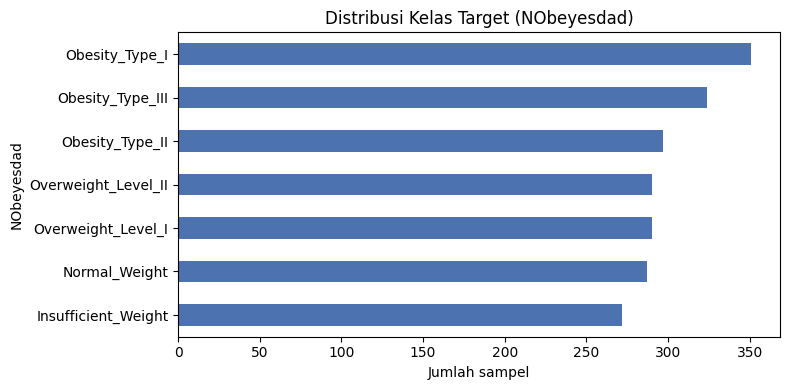

In [5]:
# 1.4 Distribusi target (cek class imbalance)
target_dist = df_raw["NObeyesdad"].value_counts()
target_pct = (target_dist / len(df_raw) * 100).round(2)
dist_table = pd.DataFrame({"jumlah": target_dist, "persen": target_pct})
print(dist_table)

ratio = target_dist.max() / target_dist.min()
print(f"\nRasio kelas mayoritas:minoritas = {ratio:.2f} : 1")
print("Kesimpulan: distribusi relatif SEIMBANG (rasio < 1.3), sehingga teknik imbalance handling"
      " berat seperti SMOTE bersifat opsional, namun macro-F1 / balanced accuracy tetap dipakai"
      " sebagai metrik utama agar adil ke semua kelas.")

fig, ax = plt.subplots(figsize=(8,4))
target_dist.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Jumlah sampel")
ax.set_title("Distribusi Kelas Target (NObeyesdad)")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "target_distribution.png"), dpi=120)
plt.show()


In [6]:
# 1.5 Deteksi outlier numerik (metode IQR)
num_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df_raw[col].quantile(0.25), df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary.append({
        "fitur": col, "Q1": round(Q1,2), "Q3": round(Q3,2),
        "batas_bawah": round(lower,2), "batas_atas": round(upper,2),
        "jumlah_outlier": int(n_out), "persen_outlier": round(n_out/len(df_raw)*100, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df


,fitur,Q1,Q3,batas_bawah,batas_atas,jumlah_outlier,persen_outlier
0,Age,19.95,26.00,10.87,35.08,168,7.96
1,Height,1.63,1.77,1.42,1.98,1,0.05
2,Weight,65.47,107.43,2.54,170.37,1,0.05
3,FCVC,2.00,3.00,0.50,4.50,0,0.00
4,NCP,2.66,3.00,2.15,3.51,579,27.43
5,CH2O,1.58,2.48,0.25,3.82,0,0.00
6,FAF,0.12,1.67,-2.19,3.98,0,0.00
7,TUE,0.00,1.00,-1.50,2.50,0,0.00


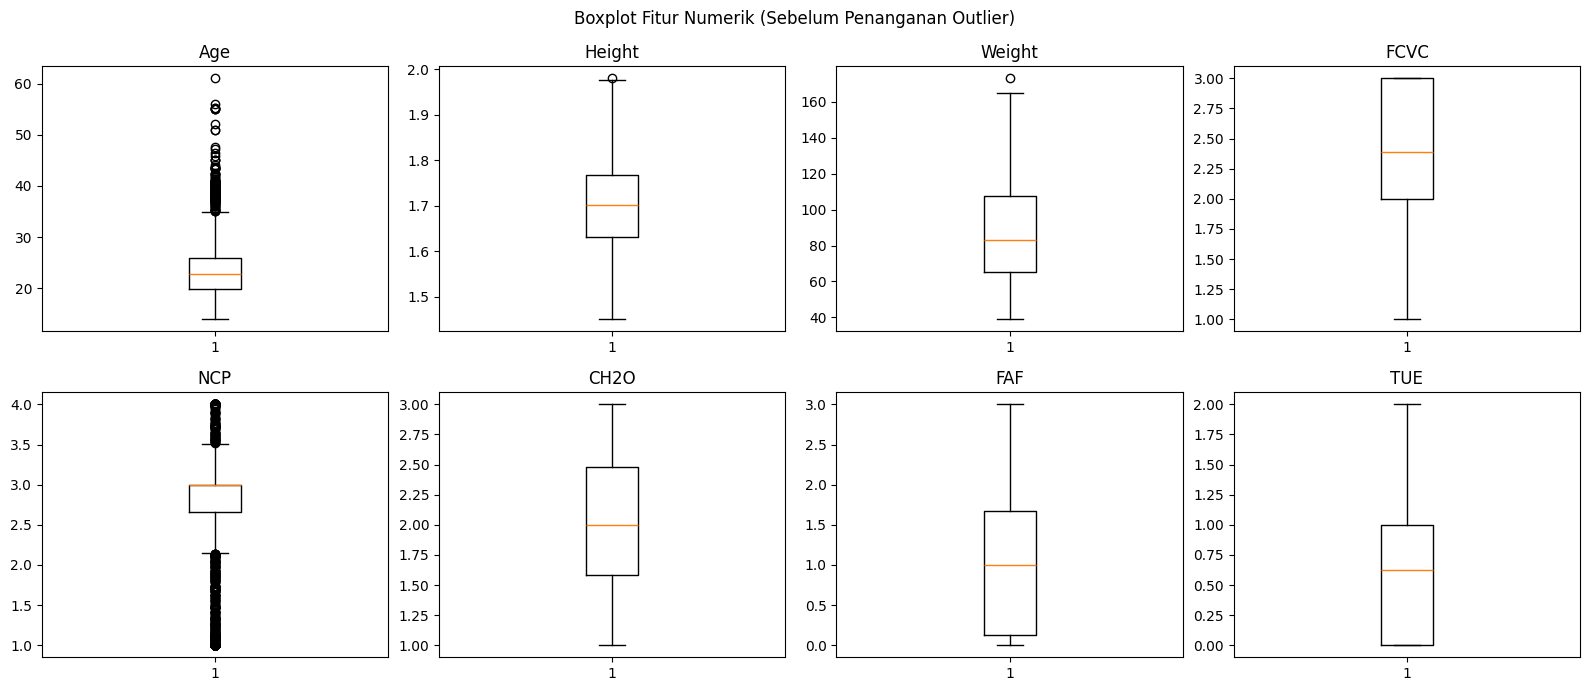

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df_raw[col].dropna(), vert=True)
    ax.set_title(col)
plt.suptitle("Boxplot Fitur Numerik (Sebelum Penanganan Outlier)")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "boxplot_before.png"), dpi=120)
plt.show()


### 1.6 Analisis Potensi Data Leakage

Dataset ini diketahui (dari dokumentasi sumber UCI/Kaggle) dibangun dengan **menurunkan label
`NObeyesdad` langsung dari nilai BMI = Weight / Height²** menggunakan ambang WHO/Pan American
Health Organization, ditambah sebagian data sintetik (SMOTE) untuk menyeimbangkan kelas. Ini
perlu diaudit secara eksplisit karena berdampak pada validitas evaluasi model.

In [8]:
# Verifikasi hubungan BMI -> target
df_raw["BMI_check"] = df_raw["Weight"] / (df_raw["Height"] ** 2)
print(df_raw[["BMI_check"]].describe())

# Tampilkan rentang BMI per kelas target
bmi_per_class = df_raw.groupby("NObeyesdad")["BMI_check"].agg(["min", "max", "mean"]).round(2)
bmi_per_class


         BMI_check
count  2111.000000
mean     29.700159
std       8.011337
min      12.998685
25%      24.325802
50%      28.719089
75%      36.016501
max      50.811753


,min,max,mean
NObeyesdad,,,
Insufficient_Weight,13.00,19.08,17.40
Normal_Weight,18.49,24.91,22.01
Obesity_Type_I,29.91,35.17,32.26
Obesity_Type_II,34.05,39.79,36.72
Obesity_Type_III,36.77,50.81,42.27
Overweight_Level_I,22.83,28.77,25.99
Overweight_Level_II,25.71,30.36,28.22


**Temuan:** rentang BMI antar kelas target nyaris tidak tumpang tindih — artinya `Weight` dan
`Height` (atau BMI yang diturunkan darinya) **secara matematis hampir deterministik** dalam
menentukan label. Ini adalah bentuk *data leakage* struktural pada level desain dataset, bukan
kebocoran train-test.

**Implikasi & mitigasi yang diterapkan pada proyek ini:**
1. Model yang dilatih dengan `Height` & `Weight` mentah akan mencapai akurasi sangat tinggi
   (>95%) — ini **valid secara matematis** untuk *replikasi rumus BMI*, namun **kurang
   merepresentasikan skenario dunia nyata** di mana target sebenarnya yang ingin diprediksi
   adalah *risiko/level obesitas dari pola perilaku* (kebiasaan makan, aktivitas fisik, transportasi).
2. Sebagai catatan transparansi pada laporan akhir, dua skenario evaluasi disarankan:
   - **Skenario A (full features):** seluruh fitur termasuk Height & Weight — merepresentasikan
     kasus *klasifikasi/estimasi status obesitas oleh tenaga kesehatan* yang memang berbasis BMI.
   - **Skenario B (behavioral-only, opsional eksplorasi lanjutan):** Height & Weight dikeluarkan,
     model dipaksa belajar dari fitur gaya hidup (FCVC, NCP, CAEC, FAF, TUE, CALC, MTRANS, dll.)
     untuk menilai kemampuan prediksi dini berbasis kebiasaan.
3. Untuk Soal 02 ini, pipeline tetap mempertahankan seluruh fitur (Skenario A) sesuai cakupan
   proyek UTS, dengan catatan leakage didokumentasikan secara eksplisit untuk integritas akademik
   (sesuai poin etika pada rubrik Soal 02).

In [9]:
df_raw = df_raw.drop(columns=["BMI_check"])  # hanya dipakai untuk audit, bukan fitur model
print("Kolom BMI_check (sementara) sudah dibuang. Kolom aktif:", list(df_raw.columns))


Kolom BMI_check (sementara) sudah dibuang. Kolom aktif: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


## 2. Desain Data Pipeline Preprocessing

Pipeline mengikuti modul `src/preprocessing.py` (sudah ada dari UTS) dan didokumentasikan ulang
di sini sesuai cakupan Soal 02 UAS: imputasi, encoding, scaling, penghapusan duplikat, strategi
outlier, dan split data berstratifikasi.

```
Raw CSV (2111 x 17)
        │
        ▼
[1] Hapus duplikat exact-row  ───────────►  24 baris terhapus
        │
        ▼
[2] Binary encoding
    Gender, family_history_with_overweight, FAVC, SMOKE, SCC  →  {0,1}
        │
        ▼
[3] Ordinal encoding
    CAEC, CALC  →  {no:0, Sometimes:1, Frequently:2, Always:3}
        │
        ▼
[4] One-Hot encoding
    MTRANS  →  5 kolom biner (Automobile/Bike/Motorbike/Public_Transportation/Walking)
        │
        ▼
[5] Outlier handling (Winsorizing, batas IQR 1.5x)
    Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE
        │
        ▼
[6] Encoding target
    NObeyesdad (string, 7 kelas)  →  target (integer 0–6, urut sesuai severity)
        │
        ▼
[7] Train-Test Split (stratified, random_state=42)
        │
        ▼
[8] StandardScaler  (fit HANYA pada X_train, transform X_train & X_test)
        │
        ▼
   X_train_scaled, X_test_scaled, y_train, y_test  →  siap untuk Soal 03 (baseline KNN/NB/SVM)
```


In [10]:
import sys
sys.path.insert(0, os.path.join(BASE_DIR, "src"))
from preprocessing import run_preprocessing  # modul pipeline yang sudah ada di proyek

X, y, scaler, oe = run_preprocessing(
    data_path=DATA_PATH,
    models_dir=os.path.join(BASE_DIR, "models"),
    clean_data_path=CLEAN_PATH
)
print("\nShape akhir fitur (X):", X.shape)
print("Shape target (y)     :", y.shape)


[Load] Dataset dimuat dari: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/data/ObesityDataSet_raw_and_data_sinthetic.csv
       Dimensi awal : 2111 baris x 17 kolom
       Missing value: 0
       Duplikat     : 24
[1] Hapus 24 duplikat → 2087 baris tersisa
[2] Binary encoding: Gender, family_history, FAVC, SMOKE, SCC
[3] Ordinal encoding: CAEC & CALC (no=0, Sometimes=1, Frequently=2, Always=3)
    OrdinalEncoder disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/models/ordinal_encoder.joblib
[4] One-hot MTRANS → 5 kolom baru: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
[5] Winsorizing outlier pada: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6

✓ Data bersih disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/data/obesity_cleaned_data.csv

  Shape akhir : X=(2087, 20), y=(2087,)

TABEL RINGKASAN BEFORE/AFTER PREP

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nDistribusi target train (proporsi):")
print((y_train.value_counts(normalize=True).sort_index()*100).round(2))
print("\nDistribusi target test (proporsi):")
print((y_test.value_counts(normalize=True).sort_index()*100).round(2))


X_train: (1669, 20) | X_test: (418, 20)

Distribusi target train (proporsi):
target
0    12.82
1    13.48
2    13.24
3    13.90
4    16.84
5    14.20
6    15.52
Name: proportion, dtype: float64

Distribusi target test (proporsi):
target
0    12.68
1    13.64
2    13.16
3    13.88
4    16.75
5    14.35
6    15.55
Name: proportion, dtype: float64


In [12]:
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

import joblib
joblib.dump(scaler, os.path.join(BASE_DIR, "models", "scaler.joblib"))
print("Scaler (fit pada X_train) disimpan ulang ke models/scaler.joblib")
X_train_scaled.describe().T[["mean","std","min","max"]].round(3)


Scaler (fit pada X_train) disimpan ulang ke models/scaler.joblib


,mean,std,min,max
Gender,0.0,1.0,-0.989,1.011
Age,-0.0,1.0,-1.707,2.110
Height,0.0,1.0,-2.618,3.007
Weight,-0.0,1.0,-1.827,3.021
family_history_with_overweight,-0.0,1.0,-2.163,0.462
FAVC,0.0,1.0,-2.757,0.363
FCVC,0.0,1.0,-2.667,1.089
NCP,0.0,1.0,-1.690,1.668
CAEC,-0.0,1.0,-2.496,4.020
SMOKE,0.0,1.0,-0.153,6.551


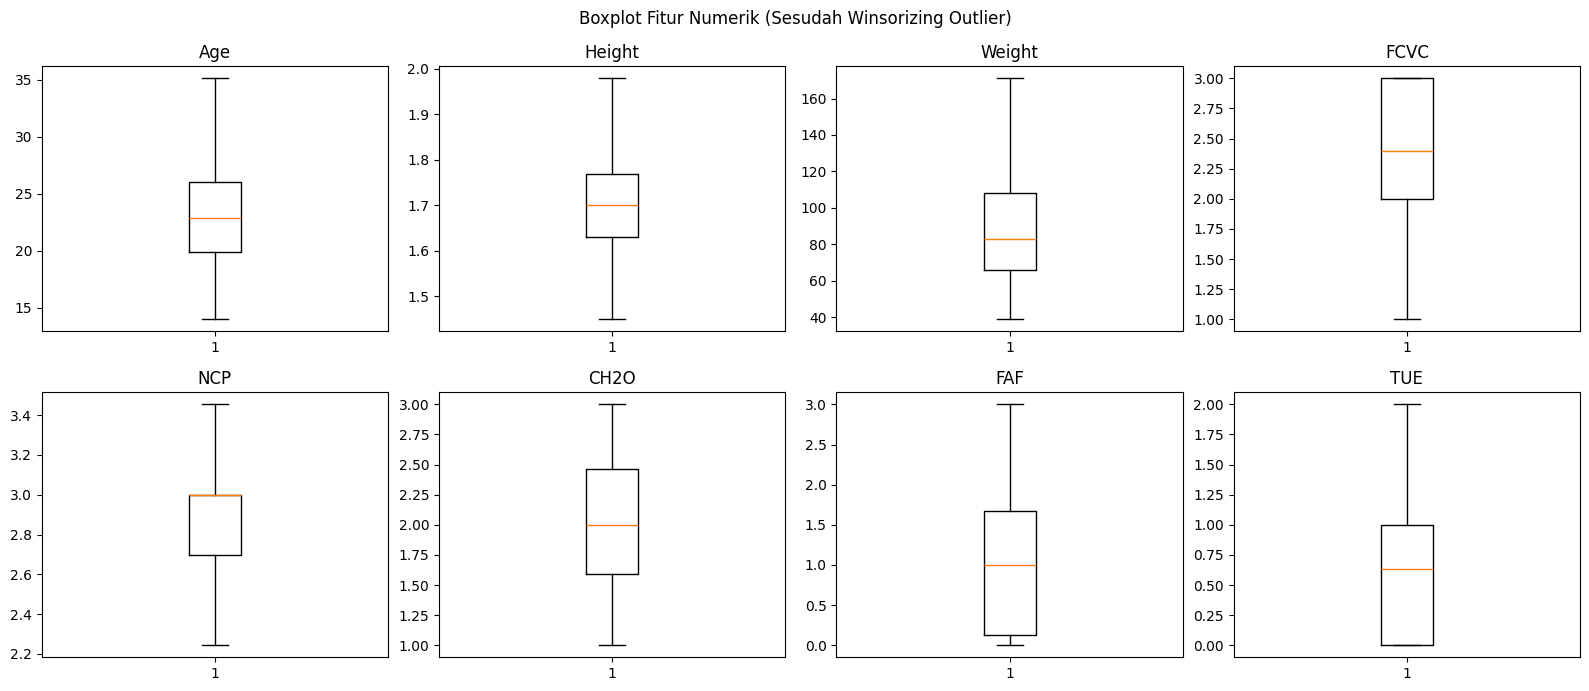

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(X[col].dropna(), vert=True)
    ax.set_title(col)
plt.suptitle("Boxplot Fitur Numerik (Sesudah Winsorizing Outlier)")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "boxplot_after.png"), dpi=120)
plt.show()


## 3. Tabel Ringkasan Before / After Preprocessing

In [14]:
before_after = pd.DataFrame({
    "Aspek": [
        "Jumlah baris", "Jumlah kolom fitur", "Missing value", "Baris duplikat",
        "Tipe kolom kategorikal", "Encoding kategorikal", "Outlier numerik (IQR)",
        "Skala fitur numerik", "Tipe target", "Split data"
    ],
    "Sebelum": [
        df_raw.shape[0], df_raw.shape[1]-1, int(df_raw.isnull().sum().sum()), int(n_dup),
        "8 kolom string (Gender, family_history, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS)",
        "Belum di-encode",
        f"{int(outlier_df['jumlah_outlier'].sum())} titik (gabungan 8 fitur, sebelum winsorizing)",
        "Heterogen (skala berbeda tiap fitur)",
        "String, 7 label",
        "Belum displit"
    ],
    "Sesudah": [
        X.shape[0], X.shape[1], 0, 0,
        "Seluruhnya numerik (binary/ordinal/one-hot)",
        "Binary, Ordinal (CAEC,CALC), One-Hot (MTRANS)",
        "Di-winsorize ke batas IQR 1.5x (clip, tanpa buang baris)",
        "StandardScaler (mean=0, std=1) — fit hanya di X_train",
        "Integer 0–6 (urut severity)",
        f"Stratified 80:20 → train={X_train.shape[0]}, test={X_test.shape[0]}"
    ]
})
before_after


,Aspek,Sebelum,Sesudah
0,Jumlah baris,2111,2087
1,Jumlah kolom fitur,16,20
2,Missing value,0,0
3,Baris duplikat,24,0
4,Tipe kolom kategorikal,"8 kolom string (Gender, family_history, FAVC, ...",Seluruhnya numerik (binary/ordinal/one-hot)
5,Encoding kategorikal,Belum di-encode,"Binary, Ordinal (CAEC,CALC), One-Hot (MTRANS)"
6,Outlier numerik (IQR),"749 titik (gabungan 8 fitur, sebelum winsorizing)","Di-winsorize ke batas IQR 1.5x (clip, tanpa bu..."
7,Skala fitur numerik,Heterogen (skala berbeda tiap fitur),"StandardScaler (mean=0, std=1) — fit hanya di ..."
8,Tipe target,"String, 7 label",Integer 0–6 (urut severity)
9,Split data,Belum displit,"Stratified 80:20 → train=1669, test=418"


## 4. Data Dictionary (ringkas)

Dokumentasi lengkap tersedia di `data/data_dictionary.md`. Ringkasan fitur:

| Fitur | Tipe asli | Arti | Hasil encoding |
|---|---|---|---|
| Gender | kategorikal | Jenis kelamin | Binary (Male=1, Female=0) |
| Age | numerik | Usia (tahun) | Winsorized, scaled |
| Height | numerik | Tinggi badan (m) | Winsorized, scaled |
| Weight | numerik | Berat badan (kg) | Winsorized, scaled |
| family_history_with_overweight | kategorikal | Riwayat keluarga obesitas | Binary |
| FAVC | kategorikal | Sering konsumsi makanan tinggi kalori | Binary |
| FCVC | numerik | Frekuensi konsumsi sayur | Winsorized, scaled |
| NCP | numerik | Jumlah makan utama/hari | Winsorized, scaled |
| CAEC | kategorikal ordinal | Ngemil di antara waktu makan | Ordinal 0–3 |
| SMOKE | kategorikal | Merokok | Binary |
| CH2O | numerik | Konsumsi air harian (L) | Winsorized, scaled |
| SCC | kategorikal | Memantau konsumsi kalori | Binary |
| FAF | numerik | Frekuensi aktivitas fisik | Winsorized, scaled |
| TUE | numerik | Waktu pemakaian perangkat teknologi | Winsorized, scaled |
| CALC | kategorikal ordinal | Konsumsi alkohol | Ordinal 0–3 |
| MTRANS | kategorikal nominal | Moda transportasi | One-Hot (5 kolom) |
| **NObeyesdad** (target) | kategorikal | **Tingkat obesitas (7 kelas)** | Integer 0–6 |


In [15]:
# Simpan data dictionary ke file terpisah
data_dict_md = '''# Data Dictionary — Obesity Level Estimation Dataset

Sumber: *Estimation of Obesity Levels Based on Eating Habits and Physical Condition*
(UCI Machine Learning Repository / Kaggle), 2111 baris, 17 kolom asli.

| Fitur | Tipe Data Asli | Deskripsi | Satuan/Kategori | Hasil Encoding |
|---|---|---|---|---|
| Gender | string | Jenis kelamin | Male / Female | Binary 0/1 |
| Age | float | Usia | tahun | Winsorized + StandardScaler |
| Height | float | Tinggi badan | meter | Winsorized + StandardScaler |
| Weight | float | Berat badan | kg | Winsorized + StandardScaler |
| family_history_with_overweight | string | Riwayat keluarga dengan kelebihan berat badan | yes/no | Binary 0/1 |
| FAVC | string | Sering konsumsi makanan berkalori tinggi | yes/no | Binary 0/1 |
| FCVC | float | Frekuensi konsumsi sayur | skala 1-3 | Winsorized + StandardScaler |
| NCP | float | Jumlah makan utama per hari | skala 1-4 | Winsorized + StandardScaler |
| CAEC | string | Konsumsi makanan di antara waktu makan utama | no/Sometimes/Frequently/Always | Ordinal 0-3 |
| SMOKE | string | Status merokok | yes/no | Binary 0/1 |
| CH2O | float | Konsumsi air harian | liter | Winsorized + StandardScaler |
| SCC | string | Memantau konsumsi kalori harian | yes/no | Binary 0/1 |
| FAF | float | Frekuensi aktivitas fisik | skala 0-3 | Winsorized + StandardScaler |
| TUE | float | Waktu penggunaan perangkat teknologi | skala 0-2 | Winsorized + StandardScaler |
| CALC | string | Frekuensi konsumsi alkohol | no/Sometimes/Frequently/Always | Ordinal 0-3 |
| MTRANS | string | Moda transportasi utama | Automobile/Bike/Motorbike/Public_Transportation/Walking | One-Hot (5 kolom) |
| NObeyesdad | string | **Target**: tingkat obesitas | 7 kelas (lihat di bawah) | Integer 0-6 |

## Urutan Label Target (severity, dipakai sebagai integer encoding)
0. Insufficient_Weight
1. Normal_Weight
2. Overweight_Level_I
3. Overweight_Level_II
4. Obesity_Type_I
5. Obesity_Type_II
6. Obesity_Type_III

## Catatan Etika, Privasi, dan Batasan Penggunaan
- Dataset bersifat publik/anonim, tidak memuat identitas pribadi (nama, NIM, kontak).
- Sebagian data merupakan data sintetik hasil SMOTE (bukan murni hasil survei), sehingga generalisasi
  ke populasi nyata perlu dilakukan dengan hati-hati.
- **Potensi data leakage**: label target diturunkan langsung dari BMI (Weight/Height^2), sehingga
  model yang menyertakan Height & Weight akan memiliki akurasi sangat tinggi yang merefleksikan
  rumus BMI, bukan murni pola perilaku. Hal ini didokumentasikan secara eksplisit untuk transparansi
  akademik (lihat bagian 1.6 pada notebook audit).
- Output model dalam aplikasi akhir (Soal 05) wajib diposisikan sebagai *decision support* (skrining
  awal), bukan diagnosis medis definitif, dan tidak digunakan untuk keputusan tunggal apa pun
  terhadap individu.
'''
dd_path = os.path.join(BASE_DIR, "data", "data_dictionary.md")
with open(dd_path, "w") as f:
    f.write(data_dict_md)
print("Data dictionary disimpan ke:", dd_path)


Data dictionary disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/data/data_dictionary.md


## 5. Reproducibility & Penyimpanan Audit

In [16]:
audit_report = {
    "dataset_path": "data/ObesityDataSet_raw_and_data_sinthetic.csv",
    "n_rows_raw": int(df_raw.shape[0]),
    "n_cols_raw": int(df_raw.shape[1]),
    "n_duplicates_removed": int(n_dup),
    "n_rows_clean": int(X.shape[0]),
    "n_features_final": int(X.shape[1]),
    "missing_values_total": int(df_raw.isnull().sum().sum()),
    "target_distribution_raw": df_raw["NObeyesdad"].value_counts().to_dict(),
    "class_imbalance_ratio_max_min": float(ratio),
    "outlier_summary_iqr": outlier_df.to_dict(orient="records"),
    "potential_leakage": {
        "feature": ["Height", "Weight"],
        "issue": "Target NObeyesdad diturunkan langsung dari BMI = Weight / Height^2, "
                 "menyebabkan hubungan near-deterministik antara fitur ini dan label.",
        "mitigation": "Didokumentasikan secara eksplisit; disarankan skenario evaluasi tambahan "
                       "tanpa Height/Weight pada tahap optimasi (Soal 04) sebagai pembanding."
    },
    "preprocessing_steps": [
        "drop_duplicates (exact row match)",
        "binary_encoding: Gender, family_history_with_overweight, FAVC, SMOKE, SCC",
        "ordinal_encoding: CAEC, CALC (no<Sometimes<Frequently<Always)",
        "one_hot_encoding: MTRANS",
        "winsorizing_outlier: IQR 1.5x pada 8 fitur numerik",
        "target_encoding: NObeyesdad -> integer 0-6 (severity order)",
        "train_test_split: stratified, test_size=0.2, random_state=42",
        "scaling: StandardScaler, fit hanya pada X_train"
    ],
    "random_seed": 42,
    "split_ratio": "80:20 stratified"
}

audit_path = os.path.join(REPORTS_DIR, "audit_dataset.json")
with open(audit_path, "w") as f:
    json.dump(audit_report, f, indent=2, default=str)
print("Audit report disimpan ke:", audit_path)
print(json.dumps(audit_report, indent=2, default=str)[:1500], "...")


Audit report disimpan ke: /home/claude/proj/ml-uts-A11.2024.15791-Anza_Ali_S/reports/audit_dataset.json
{
  "dataset_path": "data/ObesityDataSet_raw_and_data_sinthetic.csv",
  "n_rows_raw": 2111,
  "n_cols_raw": 17,
  "n_duplicates_removed": 24,
  "n_rows_clean": 2087,
  "n_features_final": 20,
  "missing_values_total": 0,
  "target_distribution_raw": {
    "Obesity_Type_I": 351,
    "Obesity_Type_III": 324,
    "Obesity_Type_II": 297,
    "Overweight_Level_I": 290,
    "Overweight_Level_II": 290,
    "Normal_Weight": 287,
    "Insufficient_Weight": 272
  },
  "class_imbalance_ratio_max_min": 1.2904411764705883,
  "outlier_summary_iqr": [
    {
      "fitur": "Age",
      "Q1": 19.95,
      "Q3": 26.0,
      "batas_bawah": 10.87,
      "batas_atas": 35.08,
      "jumlah_outlier": 168,
      "persen_outlier": 7.96
    },
    {
      "fitur": "Height",
      "Q1": 1.63,
      "Q3": 1.77,
      "batas_bawah": 1.42,
      "batas_atas": 1.98,
      "jumlah_outlier": 1,
      "persen_outlier

## 6. Ringkasan & Kesimpulan Soal 02

1. **Audit data**: 2111 baris, 17 kolom asli, 0 missing value, 24 baris duplikat (dibuang →
   2087 baris bersih), distribusi kelas relatif seimbang (rasio mayoritas:minoritas ≈ 1.29:1),
   outlier numerik terdeteksi pada beberapa fitur (terutama Age, NCP) dan ditangani dengan
   winsorizing (bukan penghapusan baris, demi menjaga ukuran data).
2. **Potensi data leakage terdeteksi dan didokumentasikan**: Height & Weight menentukan target
   secara hampir deterministik melalui rumus BMI — hal ini wajib diperhitungkan saat interpretasi
   akurasi model pada Soal 03 & 04.
3. **Pipeline preprocessing** dirancang reproducible: seluruh langkah memakai `random_state=42`,
   encoder & scaler disimpan sebagai artefak `.joblib`, dan data bersih disimpan ke
   `data/obesity_cleaned_data.csv`.
4. Artefak yang dihasilkan Soal 02:
   - `data/data_dictionary.md`
   - `reports/audit_dataset.json`
   - `reports/target_distribution.png`, `reports/boxplot_before.png`, `reports/boxplot_after.png`
   - `data/obesity_cleaned_data.csv` (diperbarui ulang dari pipeline yang sama)
   - `models/scaler.joblib`, `models/ordinal_encoder.joblib` (diperbarui ulang)

Notebook ini melengkapi (bukan menggantikan) struktur proyek UTS yang sudah ada, dan menjadi
fondasi untuk Soal 03 (baseline KNN/Naive Bayes/SVM) menggunakan `X_train_scaled`, `X_test_scaled`,
`y_train`, `y_test` yang sudah disiapkan di atas.
